<a href="https://colab.research.google.com/github/Leasgr/DiffPIR/blob/main/stage_test_DiffPIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gdown

Téléchargement des images patches_out

In [ ]:
gdown.download(
        'https://drive.google.com/uc?export=download&id=1BG0HqDYQZ0hJUwaLLs7LdVWe_liX3iZq',
        '/content/data.zip'
        )

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1BG0HqDYQZ0hJUwaLLs7LdVWe_liX3iZq
From (redirected): https://drive.google.com/uc?export=download&id=1BG0HqDYQZ0hJUwaLLs7LdVWe_liX3iZq&confirm=t&uuid=510ca4a4-7406-4eba-b9a7-702f10819dbd
To: /content/data.zip
100%|██████████| 161M/161M [00:03<00:00, 45.8MB/s]


'/content/data.zip'

In [ ]:
get_ipython().system('unzip -oq /content/data.zip -d /content')

Téléchargement des images patches_in

In [ ]:
gdown.download(
        'https://drive.google.com/uc?export=download&id=14Z4jAx2YJA3W3pJSV71aHo4KGv-Bpzi_','/content/data.zip'
        )


Downloading...
From (original): https://drive.google.com/uc?export=download&id=14Z4jAx2YJA3W3pJSV71aHo4KGv-Bpzi_
From (redirected): https://drive.google.com/uc?export=download&id=14Z4jAx2YJA3W3pJSV71aHo4KGv-Bpzi_&confirm=t&uuid=fe93a171-c453-424c-a59c-1ce6b231bf53
To: /content/data.zip
100%|██████████| 160M/160M [00:04<00:00, 36.7MB/s]


'/content/data.zip'

In [ ]:
get_ipython().system('unzip -oq /content/data.zip -d /content')

Filtrage des images. On enlèves les images contenant des nuages

In [ ]:
import numpy as np
from PIL import Image
import glob
import os

folder = "/content/patches_out"

mask_files = sorted(glob.glob(os.path.join(folder, "*_mask.png")))
print(f"Nombre de masques trouvés : {len(mask_files)}")

for f in mask_files[:5]:
    mask = np.array(Image.open(f))
    print(f"{os.path.basename(f)} -> valeurs uniques : {np.unique(mask)}")

all_values = set()
for f in mask_files:
    mask = np.array(Image.open(f))
    all_values.update(np.unique(mask).tolist())

print(f"\nToutes les valeurs uniques rencontrées dans tous les masques : {sorted(all_values)}")

Nombre de masques trouvés : 1764
S2A_MSIL1C_20230823T154821_N0510_R054_T18TXR_20241025T022611_r00000_c00000_mask.png -> valeurs uniques : [  0 128 255]
S2A_MSIL1C_20230823T154821_N0510_R054_T18TXR_20241025T022611_r00000_c00256_mask.png -> valeurs uniques : [  0 128 255]
S2A_MSIL1C_20230823T154821_N0510_R054_T18TXR_20241025T022611_r00000_c00512_mask.png -> valeurs uniques : [  0 128]
S2A_MSIL1C_20230823T154821_N0510_R054_T18TXR_20241025T022611_r00000_c00768_mask.png -> valeurs uniques : [  0 128]
S2A_MSIL1C_20230823T154821_N0510_R054_T18TXR_20241025T022611_r00000_c01024_mask.png -> valeurs uniques : [  0 128]

Toutes les valeurs uniques rencontrées dans tous les masques : [0, 128, 255]


In [ ]:
import numpy as np
from PIL import Image
import glob
import os
import shutil

folder_in = "/content/patches_in"
folder_out = "/content/patches_out"

folder_in_filtered = "/content/patches_in_filtered"
folder_out_filtered = "/content/patches_out_filtered"

os.makedirs(folder_in_filtered, exist_ok=True)
os.makedirs(folder_out_filtered, exist_ok=True)

CLOUD_VALUE = 128

# On liste tous les masques depuis patches_out
mask_files = sorted(glob.glob(os.path.join(folder_out, "*_mask.png")))
print(f"Nombre de masques trouvés : {len(mask_files)}")

kept = 0
removed = 0

for mask_path in mask_files:
    mask = np.array(Image.open(mask_path))

    has_cloud = CLOUD_VALUE in np.unique(mask)

    # Nom de base du patch (sans le suffixe _mask.png)
    mask_filename = os.path.basename(mask_path)
    base_name = mask_filename.replace("_mask.png", "")
    image_filename = base_name + ".png"

    if has_cloud:
        removed += 1
        continue

    kept += 1

    # On copie l'image satellite + son masque depuis patches_in
    shutil.copy(
        os.path.join(folder_in, image_filename),
        os.path.join(folder_in_filtered, image_filename)
    )
    shutil.copy(
        os.path.join(folder_in, mask_filename),
        os.path.join(folder_in_filtered, mask_filename)
    )

    # On copie l'image satellite + son masque depuis patches_out
    shutil.copy(
        os.path.join(folder_out, image_filename),
        os.path.join(folder_out_filtered, image_filename)
    )
    shutil.copy(
        os.path.join(folder_out, mask_filename),
        os.path.join(folder_out_filtered, mask_filename)
    )

print(f"\nPatches gardés (sans nuage) : {kept}")
print(f"Patches éliminés (avec nuage) : {removed}")
print(f"\nDossiers créés :")
print(f"  - {folder_in_filtered}")
print(f"  - {folder_out_filtered}")

Nombre de masques trouvés : 1764

Patches gardés (sans nuage) : 1689
Patches éliminés (avec nuage) : 75

Dossiers créés :
  - /content/patches_in_filtered
  - /content/patches_out_filtered


Split des images (70,15,15)

In [ ]:
import random

random.seed(42)

folder_in_filtered = "/content/patches_in_filtered"
folder_out_filtered = "/content/patches_out_filtered"

split_base = "/content/dataset_split"

# Liste des patches (basename sans extension), à partir des images (pas des masques)
image_files = sorted([
    f for f in os.listdir(folder_out_filtered)
    if f.endswith(".png") and not f.endswith("_mask.png")
])

random.shuffle(image_files)

n = len(image_files)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
# le reste va au test, pour ne perdre aucun patch aux arrondis
splits = {
    "train": image_files[:n_train],
    "val": image_files[n_train:n_train + n_val],
    "test": image_files[n_train + n_val:],
}

for split_name, files in splits.items():
    for sub in ["patches_in", "patches_out"]:
        os.makedirs(os.path.join(split_base, split_name, sub), exist_ok=True)

for split_name, files in splits.items():
    for image_filename in files:
        base_name = image_filename.replace(".png", "")
        mask_filename = base_name + "_mask.png"

        for sub, src_folder in [("patches_in", folder_in_filtered), ("patches_out", folder_out_filtered)]:
            dst_dir = os.path.join(split_base, split_name, sub)
            shutil.copy(os.path.join(src_folder, image_filename), os.path.join(dst_dir, image_filename))
            shutil.copy(os.path.join(src_folder, mask_filename), os.path.join(dst_dir, mask_filename))

print(f"Total patches : {n}")
print(f"Train : {len(splits['train'])} | Val : {len(splits['val'])} | Test : {len(splits['test'])}")

Total patches : 1689
Train : 1182 | Val : 253 | Test : 254


Clonage de mon fork de DiffPIR

In [ ]:
!git clone https://github.com/Leasgr/DiffPIR.git /content/DiffPIR

Cloning into '/content/DiffPIR'...
remote: Enumerating objects: 319, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 319 (delta 107), reused 105 (delta 98), pack-reused 186 (from 1)
Receiving objects: 100% (319/319), 43.21 MiB | 16.94 MiB/s, done.
Resolving deltas: 100% (160/160), done.


Installation des dépendances

In [ ]:
%cd /content/DiffPIR
!pip install -r requirements.txt --ignore-requires-python || true
!pip install scipy --upgrade
!pip install hdf5storage

/content/DiffPIR
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu117
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 60.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 53.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.5 

Clonage de motionblur (pas utile pour nous mais si on ne fait pas le téléchargement le code ne marche pas)

In [ ]:
!git clone https://github.com/LeviBorodenko/motionblur.git /content/DiffPIR/motionblur

Cloning into '/content/DiffPIR/motionblur'...
remote: Enumerating objects: 36, done.
remote: Total 36 (delta 0), reused 0 (delta 0), pack-reused 36 (from 1)
Receiving objects: 100% (36/36), 511.08 KiB | 46.46 MiB/s, done.
Resolving deltas: 100% (12/12), done.


Téléchargement du checkpoint Imagenet, le modèle de diffusion pré-entraîné par OpenAI sur ImageNet, qui va nous servir de point de départ pour le fine-tuning.

In [ ]:
!wget https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_diffusion_uncond.pt -O /content/DiffPIR/model_zoo/256x256_diffusion_uncond.pt

--2026-07-21 23:58:17--  https://openaipublic.blob.core.windows.net/diffusion/jul-2021/256x256_diffusion_uncond.pt
Resolving openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)... 57.150.144.33
Connecting to openaipublic.blob.core.windows.net (openaipublic.blob.core.windows.net)|57.150.144.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2211383297 (2.1G) [application/octet-stream]
Saving to: ‘/content/DiffPIR/model_zoo/256x256_diffusion_uncond.pt’

/content/DiffPIR/mo 100%[===================>]   2.06G  2.77MB/s    in 15m 3s  

2026-07-22 00:13:21 (2.34 MB/s) - ‘/content/DiffPIR/model_zoo/256x256_diffusion_uncond.pt’ saved [2211383297/2211383297]



## Correction du chargement du checkpoint

On ajoute `strict=False` pour permettre le chargement du checkpoint OpenAI
malgré de légères différences de nommage des couches entre versions du code.

In [ ]:
with open("/content/DiffPIR/guided_diffusion/train_util.py", "r") as f:
    content = f.read()

old = """                self.model.load_state_dict(
                    dist_util.load_state_dict(
                        resume_checkpoint, map_location=dist_util.dev()
                    )
                )"""

new = """                self.model.load_state_dict(
                    dist_util.load_state_dict(
                        resume_checkpoint, map_location=dist_util.dev()
                    ), strict=False
                )"""

content = content.replace(old, new)

with open("/content/DiffPIR/guided_diffusion/train_util.py", "w") as f:
    f.write(content)

print("Correction appliquée !")

Correction appliquée !


Fine tuning à partir du nouveau fichier d'entrainement image_train.py

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

logdir = "/content/drive/MyDrive/Stage Léa Sagroun/checkpoints_diffpir"
os.makedirs(logdir, exist_ok=True)
os.environ["OPENAI_LOGDIR"] = logdir

print("Checkpoints sauvegardés dans :", logdir)

Mounted at /content/drive
Checkpoints sauvegardés dans : /content/drive/MyDrive/Stage Léa Sagroun/checkpoints_diffpir


Nettoyage automatique des vieux checkpoints pour gérer au mieux le stockage

In [ ]:
import threading
import time
import glob
import os
import re

def cleanup_old_checkpoints(logdir, keep_last=3, check_interval=120):
    """
    Garde uniquement les `keep_last` steps les plus récents.
    Supprime pour chaque step supprimé : model*.pt, ema_*.pt, opt*.pt
    """
    while True:
        time.sleep(check_interval)
        try:
            # on repère tous les numéros de step à partir des fichiers modelNNNNNN.pt
            model_files = glob.glob(os.path.join(logdir, "model*.pt"))
            steps = sorted(set(
                int(re.search(r"model(\d+)\.pt", os.path.basename(f)).group(1))
                for f in model_files
                if re.search(r"model(\d+)\.pt", os.path.basename(f))
            ))

            if len(steps) <= keep_last:
                continue

            steps_to_delete = steps[:-keep_last]  # tous sauf les N derniers

            for step in steps_to_delete:
                step_str = f"{step:06d}"
                # supprime model, toutes les versions ema, et opt pour ce step
                for f in glob.glob(os.path.join(logdir, f"*{step_str}.pt")):
                    os.remove(f)
                    print(f"[cleanup] supprimé : {f}")

        except Exception as e:
            print(f"[cleanup] erreur (ignorée) : {e}")

# lance le nettoyage en arrière-plan (vérifie toutes les 2 min, garde les 3 derniers steps)
cleanup_thread = threading.Thread(
    target=cleanup_old_checkpoints,
    args=(logdir, 3, 120),
    daemon=True
)
cleanup_thread.start()
print("Nettoyage automatique des checkpoints démarré en arrière-plan.")

Nettoyage automatique des checkpoints démarré en arrière-plan.


In [ ]:
%cd /content/DiffPIR
!python scripts/image_train.py \
    --data_dir /content/dataset_split/train/patches_in \
    --resume_checkpoint model_zoo/256x256_diffusion_uncond.pt \
    --image_size 256 --num_channels 256 --num_res_blocks 2 \
    --attention_resolutions 8,16,32 --learn_sigma True \
    --class_cond False \
    --lr 2e-5 --batch_size 2 --microbatch 1 \
    --use_fp16 True --use_checkpoint True \
    --log_interval 50 --save_interval 2000

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
| mse           | 0.0051   |
| mse_q0        | 0.0181   |
| mse_q1        | 0.0014   |
| mse_q2        | 0.000443 |
| mse_q3        | 3.67e-05 |
| param_norm    | 1.22e+03 |
| samples       | 2.93e+04 |
| step          | 1.46e+04 |
| vb            | 0.000476 |
| vb_q0         | 0.00182  |
| vb_q1         | 1.03e-05 |
| vb_q2         | 3.96e-06 |
| vb_q3         | 4.53e-07 |
----------------------------
----------------------------
| grad_norm     | 0.028    |
| lg_loss_scale | 17.7     |
| loss          | 0.00319  |
| loss_q0       | 0.0119   |
| loss_q1       | 0.00151  |
| loss_q2       | 0.000352 |
| loss_q3       | 3.89e-05 |
| mse           | 0.00283  |
| mse_q0        | 0.0103   |
| mse_q1        | 0.0015   |
| mse_q2        | 0.000349 |
| mse_q3        | 3.84e-05 |
| param_norm    | 1.22e+03 |
| samples       | 2.94e+04 |
| step          | 1.47e+04 |
| vb            | 0.000356 |
| vb_q0         | 0.001

On regarde à quoi ressemble les chekpoints enregistrés dans le drive

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

logdir = "/content/drive/MyDrive/Stage Léa Sagroun/checkpoints_diffpir"
df = pd.read_csv(f"{logdir}/progress.csv")

print(f"Nombre de lignes de log : {len(df)}")
print(f"Steps couverts : {df['step'].min():.0f} → {df['step'].max():.0f}")
print(df.columns.tolist())
df.tail()

Nombre de lignes de log : 519
Steps couverts : 0 → 25900
['grad_norm', 'lg_loss_scale', 'loss', 'loss_q1', 'mse', 'mse_q1', 'param_norm', 'samples', 'step', 'vb', 'vb_q1', 'loss_q0', 'loss_q2', 'loss_q3', 'mse_q0', 'mse_q2', 'mse_q3', 'vb_q0', 'vb_q2', 'vb_q3']


,grad_norm,lg_loss_scale,loss,loss_q1,mse,mse_q1,param_norm,samples,step,vb,vb_q1,loss_q0,loss_q2,loss_q3,mse_q0,mse_q2,mse_q3,vb_q0,vb_q2,vb_q3
514,0.038618,18.64850,0.004838,0.001610,0.004492,0.001599,1223.008825,51402,25700,0.000345,0.000012,0.016225,0.000316,0.000041,0.014959,0.000313,0.000040,0.001266,0.000003,5.259916e-07
515,0.058738,18.69850,0.004466,0.001504,0.004125,0.001493,1223.009079,51502,25750,0.000341,0.000011,0.013121,0.000276,0.000048,0.012031,0.000274,0.000048,0.001090,0.000002,5.798644e-07
516,0.025606,18.74850,0.003237,0.001882,0.003159,0.001869,1223.009668,51602,25800,0.000078,0.000014,0.009851,0.000343,0.000039,0.009578,0.000340,0.000038,0.000273,0.000003,4.922831e-07
517,0.028940,17.83754,0.026820,0.002945,0.007452,0.002923,1223.009848,51702,25850,0.019369,0.000022,0.086654,0.000204,0.000055,0.022113,0.000202,0.000055,0.064541,0.000002,6.938191e-07
518,0.019920,17.84750,0.001809,0.001069,0.001750,0.001062,1223.010019,51802,25900,0.000059,0.000008,0.006745,0.000202,0.000039,0.006490,0.000201,0.000039,0.000256,0.000002,4.814931e-07


Représentations graphique des résultats

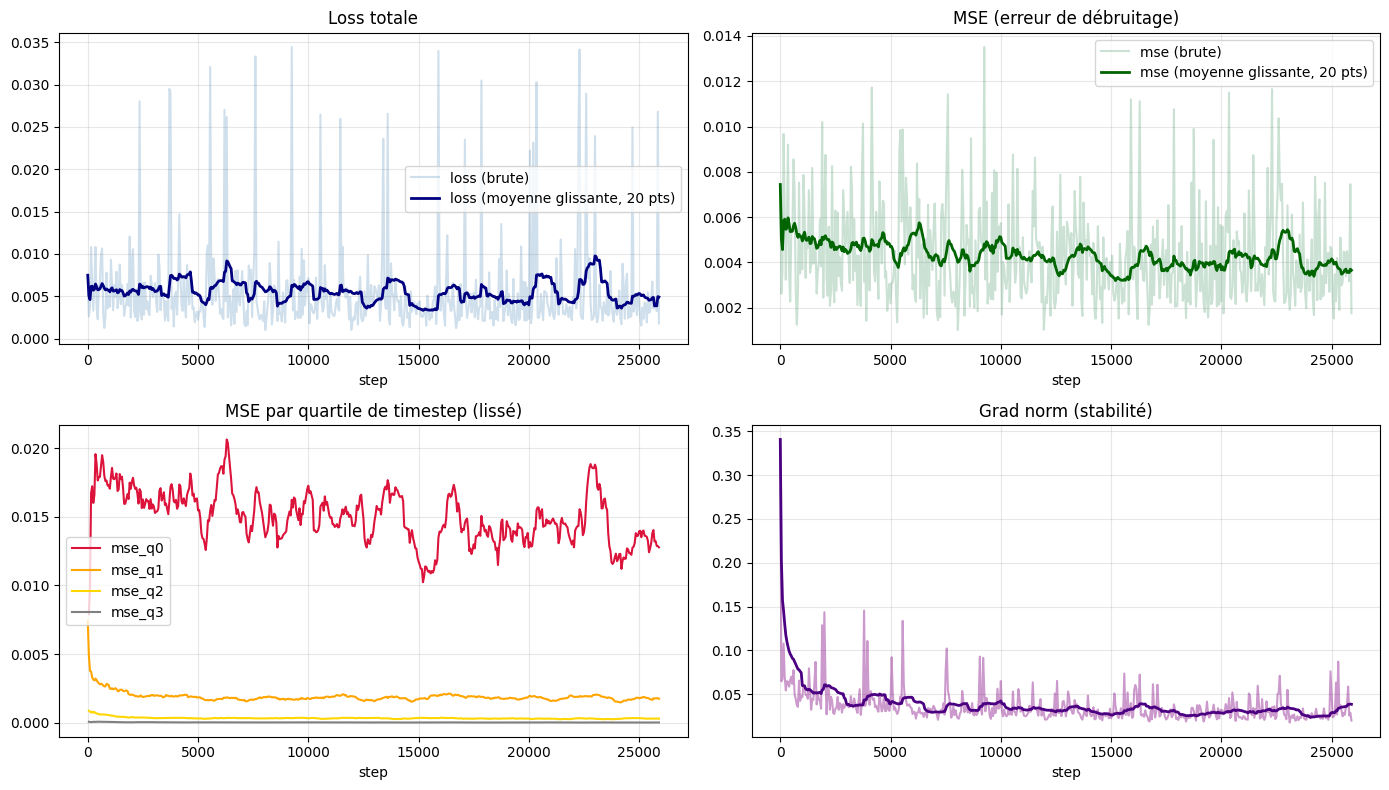


--- Résumé ---
Loss moyenne (steps 0-2000)     : 0.00570
Loss moyenne (2000 derniers steps) : 0.00501
MSE moyenne (steps 0-2000)      : 0.00510
MSE moyenne (2000 derniers steps)  : 0.00383


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

logdir = "/content/drive/MyDrive/Stage Léa Sagroun/checkpoints_diffpir"
df = pd.read_csv(f"{logdir}/progress.csv")

# Moyenne glissante pour lisser le bruit d'un step à l'autre
window = 20  # ~1000 steps de fenêtre (20 x log_interval de 50)
df['loss_smooth'] = df['loss'].rolling(window, min_periods=1).mean()
df['mse_smooth'] = df['mse'].rolling(window, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Loss brute vs lissée
axes[0, 0].plot(df['step'], df['loss'], alpha=0.25, color='steelblue', label='loss (brute)')
axes[0, 0].plot(df['step'], df['loss_smooth'], color='navy', linewidth=2, label=f'loss (moyenne glissante, {window} pts)')
axes[0, 0].set_title('Loss totale')
axes[0, 0].set_xlabel('step')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. MSE brute vs lissée
axes[0, 1].plot(df['step'], df['mse'], alpha=0.25, color='seagreen', label='mse (brute)')
axes[0, 1].plot(df['step'], df['mse_smooth'], color='darkgreen', linewidth=2, label=f'mse (moyenne glissante, {window} pts)')
axes[0, 1].set_title('MSE (erreur de débruitage)')
axes[0, 1].set_xlabel('step')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. MSE par quartile de timestep (q0 = très bruité/difficile, q3 = peu bruité/facile)
for q, color in zip(['mse_q0', 'mse_q1', 'mse_q2', 'mse_q3'], ['crimson', 'orange', 'gold', 'gray']):
    smooth = df[q].rolling(window, min_periods=1).mean()
    axes[1, 0].plot(df['step'], smooth, label=q, color=color)
axes[1, 0].set_title('MSE par quartile de timestep (lissé)')
axes[1, 0].set_xlabel('step')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. grad_norm (stabilité de l'entraînement)
axes[1, 1].plot(df['step'], df['grad_norm'], alpha=0.4, color='purple')
axes[1, 1].plot(df['step'], df['grad_norm'].rolling(window, min_periods=1).mean(), color='indigo', linewidth=2)
axes[1, 1].set_title('Grad norm (stabilité)')
axes[1, 1].set_xlabel('step')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Stage Léa Sagroun/loss_curves.png', dpi=150)
plt.show()

# Résumé chiffré : début vs fin
print(f"\n--- Résumé ---")
print(f"Loss moyenne (steps 0-2000)     : {df[df['step']<=2000]['loss'].mean():.5f}")
print(f"Loss moyenne (2000 derniers steps) : {df[df['step']>=df['step'].max()-2000]['loss'].mean():.5f}")
print(f"MSE moyenne (steps 0-2000)      : {df[df['step']<=2000]['mse'].mean():.5f}")
print(f"MSE moyenne (2000 derniers steps)  : {df[df['step']>=df['step'].max()-2000]['mse'].mean():.5f}")